## Section 1 — Environment Setup & Imports

**What this does:**
Centralises all imports, sets global constants, configures the compute device, and seeds all RNGs for reproducibility.

**Changes from v1:** Added `torch.nn.functional as F` (required by FocalLoss) and `import copy` (required for best-checkpoint restore).

**Expected Output:** `Using device: cuda` (or `cpu`).

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

import os
import copy
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F          # NEW: required by FocalLoss
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler, ConcatDataset
import torchvision
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import EfficientNet_B0_Weights, ViT_B_16_Weights
import torchmetrics
from sklearn.metrics import confusion_matrix

# ── Global Constants ──────────────────────────────────────────
DATASET_PATH = "/home/allkeeey/projects/ai-vs-real-detector/image_data"

# ── Reproducibility ──────────────────────────────────────────
def seed_everything(seed: int = 42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

# ── Device ────────────────────────────────────────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## Section 2 — Dataset Exploration & Class Imbalance Analysis

**What this does:**
Loads the dataset for EDA only, counts samples per class, computes the imbalance ratio, and plots the distribution.

**Reasoning:**
Inspecting class distribution before modelling is mandatory — it dictates every downstream decision about sampling strategy and loss function weighting.

**Expected Output:** Class counts, imbalance ratio, and a bar chart.

Class to Index Mapping: {'Ai_generated_dataset': 0, 'real_dataset': 1}

Total images: 995
  Ai_generated_dataset (Class 0): 250 images
  real_dataset (Class 1): 745 images

Imbalance Ratio (Ai_generated_dataset to real_dataset): 0.34:1


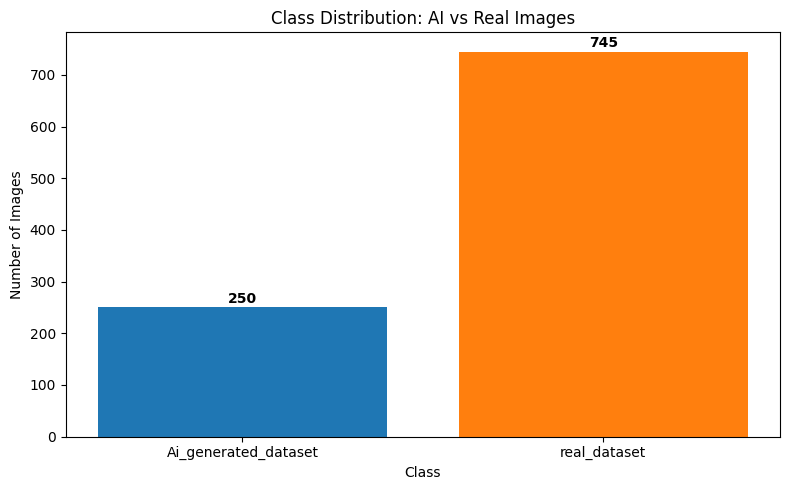

In [2]:
# Minimal transform strictly for EDA
eda_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

eda_dataset = ImageFolder(root=DATASET_PATH, transform=eda_transform)

class_names   = eda_dataset.classes
class_to_idx  = eda_dataset.class_to_idx
print(f"Class to Index Mapping: {class_to_idx}")

targets       = eda_dataset.targets
class_counts  = [targets.count(i) for i in range(len(class_names))]
total_count   = sum(class_counts)

print(f"\nTotal images: {total_count}")
for i, name in enumerate(class_names):
    print(f"  {name} (Class {i}): {class_counts[i]} images")

imbalance_ratio = class_counts[0] / class_counts[1]
print(f"\nImbalance Ratio ({class_names[0]} to {class_names[1]}): {imbalance_ratio:.2f}:1")

plt.figure(figsize=(8, 5))
plt.bar(class_names, class_counts, color=['#1f77b4', '#ff7f0e'])
plt.title('Class Distribution: AI vs Real Images')
plt.ylabel('Number of Images')
plt.xlabel('Class')
for i, count in enumerate(class_counts):
    plt.text(i, count + 3, str(count), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

## Section 3 — Augmentation Strategy & Shared Eval Transform

**What this does:**
Defines `train_transforms` (augmented) and `eval_transforms` (clean). Augmentation is online — applied randomly every epoch, giving practically unlimited variation without touching disk.

**Changes from v1:**
- Added `transforms.RandomErasing(p=0.2, ...)` — occludes small random patches, forcing the model to rely on global texture rather than single regions. Pure regularisation gain.

**Intentional omissions:**
- No `GaussianBlur` / `GaussianNoise` — AI-generated images carry high-frequency checkerboard artefacts and diffusion-specific texture signatures. Blurring destroys exactly the signal the model needs.

**Expected Output:** Two `Compose` objects in memory.

In [3]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    # NEW ↓ — occludes 2–15 % of image area; forces texture-level generalisation
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15), ratio=(0.3, 3.3))
])

eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Transforms defined.")
print(f"  train_transforms: {len(train_transforms.transforms)} stages")
print(f"  eval_transforms:  {len(eval_transforms.transforms)} stages")

Transforms defined.
  train_transforms: 9 stages
  eval_transforms:  3 stages


## Section 4 — Train/Val/Test Split & WeightedRandomSampler

**What this does:**
Reusable `build_dataloaders` that splits data 70/15/15, applies correct transforms to each split, and builds a `WeightedRandomSampler` so every training batch is approximately balanced.

**Unchanged from v1** — the split and sampling logic is correct as-is.

**Expected Output:** Function definition.

In [4]:
def build_dataloaders(
    dataset_path: str,
    train_transform: transforms.Compose,
    eval_transform: transforms.Compose,
    train_ratio: float = 0.70,
    val_ratio: float   = 0.15,
    batch_size: int    = 32,
    use_combined_train_val: bool = False
) -> tuple:

    # Load dataset twice — different transforms for train vs eval splits
    dataset_train = ImageFolder(root=dataset_path, transform=train_transform)
    dataset_eval  = ImageFolder(root=dataset_path, transform=eval_transform)

    total_len = len(dataset_train)
    train_len = int(train_ratio * total_len)
    val_len   = int(val_ratio   * total_len)
    test_len  = total_len - train_len - val_len

    generator = torch.Generator().manual_seed(42)

    train_subset_train, val_subset_train, test_subset_train = random_split(
        dataset_train, [train_len, val_len, test_len], generator=generator
    )
    train_subset_eval, val_subset_eval, test_subset_eval = random_split(
        dataset_eval,  [train_len, val_len, test_len], generator=generator
    )

    val_dataset  = val_subset_eval
    test_dataset = test_subset_eval

    if use_combined_train_val:
        active_train_dataset = ConcatDataset([train_subset_train, val_subset_train])
    else:
        active_train_dataset = train_subset_train

    # ── WeightedRandomSampler ─────────────────────────────────
    train_targets = []
    if use_combined_train_val:
        for idx in train_subset_train.indices:
            train_targets.append(dataset_train.targets[idx])
        for idx in val_subset_train.indices:
            train_targets.append(dataset_train.targets[idx])
    else:
        for idx in train_subset_train.indices:
            train_targets.append(dataset_train.targets[idx])

    tr_class_counts  = [train_targets.count(0), train_targets.count(1)]
    class_weights_s  = 1.0 / torch.tensor(tr_class_counts, dtype=torch.float)
    sample_weights   = [class_weights_s[t] for t in train_targets]

    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )

    train_dataloader = DataLoader(active_train_dataset, batch_size=batch_size, sampler=sampler)
    val_dataloader   = DataLoader(val_dataset,          batch_size=batch_size, shuffle=False)
    test_dataloader  = DataLoader(test_dataset,         batch_size=batch_size, shuffle=False)

    return train_dataloader, val_dataloader, test_dataloader, dataset_train.classes

## Section 5 — Focal Loss & Shared Metrics

**What this does:**
Defines `FocalLoss` and initialises `torchmetrics` evaluation objects.

**Changes from v1 (critical):**

1. **`FocalLoss` replaces both `standard_loss_fn` and `weighted_loss_fn`.**
   Focal Loss combines class weighting (via `alpha`) with a dynamic down-weighting of easy examples (via `gamma`). This is strictly superior to weighted CrossEntropy for imbalanced, data-scarce problems.

2. **Removed `weights[1] *= 5.0`.**
   The original code applied a hardcoded 5× multiplier on top of already inverse-frequency-weighted values. This was a magic number that risked collapsing all predictions toward one class for downstream models. The `alpha` passed to FocalLoss is simply the normalised inverse-frequency weight — no arbitrary scaling.

**Expected Output:** FocalLoss and metric objects instantiated and moved to device.

In [5]:
# ── Focal Loss ───────────────────────────────────────────────
class FocalLoss(nn.Module):
    """
    Handles class imbalance better than weighted CrossEntropy.

    alpha : per-class weight tensor (inverse frequency, normalised).
            Higher weight → higher penalty for misclassifying that class.
    gamma : focusing parameter. 0 = vanilla weighted CE. 2.0 is standard.
            Higher gamma → more focus on hard, misclassified examples.
    """
    def __init__(self, alpha: torch.Tensor = None, gamma: float = 2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce_loss      = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        pt           = torch.exp(-ce_loss)          # probability of correct class
        focal_weight = (1 - pt) ** self.gamma       # down-weight easy examples
        return (focal_weight * ce_loss).mean()


# ── Alpha weights from EDA class counts ──────────────────────
# class_counts is set in Section 2.  AI=index 0, Real=index 1 (verify with class_to_idx)
alpha_raw     = 1.0 / torch.tensor(class_counts, dtype=torch.float)
alpha_weights = (alpha_raw / alpha_raw.sum()).to(device)   # normalise — no magic multiplier

print(f"Alpha weights → {class_names[0]}: {alpha_weights[0]:.4f} | {class_names[1]}: {alpha_weights[1]:.4f}")

focal_loss_fn = FocalLoss(alpha=alpha_weights, gamma=2.0)

# ── Torchmetrics (task='binary' for 2-class problem) ─────────
acc_fn       = torchmetrics.Accuracy(task="binary").to(device)
f1_fn        = torchmetrics.F1Score(task="binary").to(device)
precision_fn = torchmetrics.Precision(task="binary").to(device)
recall_fn    = torchmetrics.Recall(task="binary").to(device)

print("\nFocal Loss and metrics initialised.")

Alpha weights → Ai_generated_dataset: 0.7487 | real_dataset: 0.2513

Focal Loss and metrics initialised.


## Section 6 — Train Step & Test Step

**What this does:**
Single-epoch forward/backward pass with metric accumulation.

**Unchanged from v1** — the metric `.reset()` pattern, `softmax` probability extraction, and `torch.inference_mode()` are all correct.

**Expected Output:** Two function definitions.

In [6]:
def train_step(
    model:        torch.nn.Module,
    data_loader:  DataLoader,
    loss_fn:      torch.nn.Module,
    optimizer:    torch.optim.Optimizer,
    acc_fn, f1_fn, precision_fn, recall_fn,
    device:       str
) -> dict:

    acc_fn.reset(); f1_fn.reset(); precision_fn.reset(); recall_fn.reset()

    model.train()
    train_loss = 0.0

    for X, y in data_loader:
        X, y = X.to(device), y.to(device)

        y_pred_logits = model(X)
        y_pred_probs  = torch.softmax(y_pred_logits, dim=1)[:, 1]

        loss = loss_fn(y_pred_logits, y)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        acc_fn(y_pred_probs, y)
        f1_fn(y_pred_probs, y)
        precision_fn(y_pred_probs, y)
        recall_fn(y_pred_probs, y)

    return {
        "loss":      train_loss / len(data_loader),
        "accuracy":  acc_fn.compute().item(),
        "f1":        f1_fn.compute().item(),
        "precision": precision_fn.compute().item(),
        "recall":    recall_fn.compute().item()
    }


def test_step(
    model:       torch.nn.Module,
    data_loader: DataLoader,
    loss_fn:     torch.nn.Module,
    acc_fn, f1_fn, precision_fn, recall_fn,
    device:      str
) -> dict:

    acc_fn.reset(); f1_fn.reset(); precision_fn.reset(); recall_fn.reset()

    model.eval()
    test_loss = 0.0

    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)

            y_pred_logits = model(X)
            y_pred_probs  = torch.softmax(y_pred_logits, dim=1)[:, 1]

            loss       = loss_fn(y_pred_logits, y)
            test_loss += loss.item()

            acc_fn(y_pred_probs, y)
            f1_fn(y_pred_probs, y)
            precision_fn(y_pred_probs, y)
            recall_fn(y_pred_probs, y)

    return {
        "loss":      test_loss / len(data_loader),
        "accuracy":  acc_fn.compute().item(),
        "f1":        f1_fn.compute().item(),
        "precision": precision_fn.compute().item(),
        "recall":    recall_fn.compute().item()
    }

## Section 7 — Training Loop, History Plotter & Confusion Matrix Utility

**What this does:**
`train_model` orchestrates epochs and checkpointing. `plot_history` produces three training curves. `plot_confusion_matrix` is now defined here as a shared utility (reused by all models).

**Changes from v1 (all high-priority):**

| Change | Reason |
|---|---|
| `CosineAnnealingLR` scheduler | Smoothly decays LR to `eta_min=1e-6` — avoids oscillation near convergence |
| Best-checkpoint saving (by val F1) | Saves the epoch with highest val F1, not the final epoch — crucial if overfitting occurs |
| `model.load_state_dict(best_weights)` at end | Model returned is always the best-generalising version |
| Early stopping (`patience=8`) | Halts training once val F1 stops improving for 8 consecutive epochs |
| History now tracks F1 alongside loss & accuracy | F1 is the correct primary metric for imbalanced classification |
| Three-panel `plot_history` | Loss / Accuracy / F1 all visible at once |

**Expected Output:** Function definitions.

In [7]:
from tqdm import tqdm

def train_model(
    model:        torch.nn.Module,
    train_loader: DataLoader,
    val_loader:   DataLoader,
    loss_fn:      torch.nn.Module,
    optimizer:    torch.optim.Optimizer,
    epochs:       int,
    acc_fn, f1_fn, precision_fn, recall_fn,
    device:       str,
    model_name:   str,
    patience:     int = 8
) -> dict:
    """
    Trains model with:
      - CosineAnnealingLR scheduler
      - Best-checkpoint saving keyed on val F1 (not accuracy)
      - Early stopping after `patience` epochs without val F1 improvement
    Returns full history dict including F1 curves.
    """

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-6
    )

    history = {
        "train_loss": [], "train_acc": [], "train_f1": [],
        "val_loss":   [], "val_acc":   [], "val_f1":   []
    }

    best_val_f1  = 0.0
    best_weights = copy.deepcopy(model.state_dict())
    patience_ctr = 0
    best_path    = f"{model_name}_best.pth"

    for epoch in tqdm(range(epochs), desc=f"Training {model_name}"):

        train_metrics = train_step(
            model, train_loader, loss_fn, optimizer,
            acc_fn, f1_fn, precision_fn, recall_fn, device
        )
        val_metrics = test_step(
            model, val_loader, loss_fn,
            acc_fn, f1_fn, precision_fn, recall_fn, device
        )
        scheduler.step()

        history["train_loss"].append(train_metrics["loss"])
        history["train_acc"].append(train_metrics["accuracy"])
        history["train_f1"].append(train_metrics["f1"])
        history["val_loss"].append(val_metrics["loss"])
        history["val_acc"].append(val_metrics["accuracy"])
        history["val_f1"].append(val_metrics["f1"])

        # ── Best checkpoint by val F1 ─────────────────────────
        if val_metrics["f1"] > best_val_f1:
            best_val_f1  = val_metrics["f1"]
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, best_path)
            patience_ctr = 0
        else:
            patience_ctr += 1

        # ── Early stopping ────────────────────────────────────
        if patience_ctr >= patience:
            print(f"\nEarly stopping at epoch {epoch + 1} | Best Val F1: {best_val_f1:.4f}")
            break

    # Restore best weights into the model before returning
    model.load_state_dict(best_weights)
    print(f"Best model restored ({best_path}) | Val F1: {best_val_f1:.4f}")

    return history


def plot_history(history: dict, model_name: str) -> None:
    """Three-panel plot: Loss | Accuracy | F1 Score."""
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"{model_name} — Training History", fontsize=14)

    panels = [
        ("train_loss", "val_loss", "Loss Curves",     "Loss"),
        ("train_acc",  "val_acc",  "Accuracy Curves", "Accuracy"),
        ("train_f1",   "val_f1",   "F1 Curves",       "F1 Score"),
    ]
    for ax, (train_key, val_key, title, ylabel) in zip(axes, panels):
        ax.plot(epochs, history[train_key], label=f"Train", marker="o", markersize=3)
        ax.plot(epochs, history[val_key],   label=f"Val",   marker="o", markersize=3)
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.legend()

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(
    model:       nn.Module,
    data_loader: DataLoader,
    class_names: list,
    device:      str,
    title:       str
) -> None:
    """Shared confusion matrix utility — used by all models."""
    model.eval()
    y_true, y_pred = [], []
    with torch.inference_mode():
        for X, y in data_loader:
            X      = X.to(device)
            logits = model(X)
            preds  = torch.argmax(logits, dim=1)
            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

## Section 8 — Model 0: TinyVGG (Trained From Scratch)

Baseline CNN. Establishes a performance floor for transfer learning models to beat.

**Architecture changes from v1:**

| Component | v1 | v2 | Reason |
|---|---|---|---|
| Convs per block | 1 | 2 | Richer feature hierarchy; standard VGG design |
| Spatial output before classifier | 4 × 4 = 16 | 1 × 1 = 1 | Global Avg Pool reduces 2,048-dim input to 128 — critical for 280-sample train set |
| Classifier input dim | `128 × 4 × 4 = 2048` | `128 × 1 × 1 = 128` | Reduces overfit risk dramatically |
| Second dropout | ✗ | ✓ (p=0.3) | Extra regularisation in classifier head |

**Training changes from v1:**

| Config | v1 | v2 | Reason |
|---|---|---|---|
| Loss | `standard_loss_fn` (unweighted CE) | `focal_loss_fn` | Handles imbalance + hard examples jointly |
| Epochs | 15 (fixed) | 50 (+ early stopping, patience=8) | 15 epochs almost certainly under-converges |
| LR schedule | None (flat 1e-3) | CosineAnnealingLR | Smoother convergence, avoids LR oscillation |
| Checkpoint | Final epoch | Best val F1 epoch | Saves best-generalising model, not last |

### Sub-cell 8a — Upgraded TinyVGG Architecture

In [8]:
seed_everything(42)

class TinyVGG(nn.Module):
    """
    TinyVGG v2 — two changes from v1:
      1. Two Conv layers per block (standard VGG design for richer feature hierarchy)
      2. Global Average Pooling replaces AdaptiveAvgPool2d(4,4)
         → classifier input: 128 dims instead of 2048, massively reducing overfit on small data
    """
    def __init__(self, in_channels: int, num_classes: int):
        super().__init__()

        def conv_block(in_c: int, out_c: int) -> nn.Sequential:
            return nn.Sequential(
                nn.Conv2d(in_c,  out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(),
                nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),  # second conv
                nn.BatchNorm2d(out_c),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2)
            )

        self.block_1 = conv_block(in_channels, 32)   # 3  → 32 channels
        self.block_2 = conv_block(32, 64)             # 32 → 64 channels
        self.block_3 = conv_block(64, 128)            # 64 → 128 channels

        # Global Average Pool: (N, 128, H, W) → (N, 128, 1, 1)
        # Collapses each channel to a single scalar → robust, position-invariant features
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        # Classifier: 128 input dims (was 2048 with 4×4 pool)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Dropout(0.3),          # second dropout layer
            nn.Linear(256, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.block_3(x)
        x = self.pool(x)
        return self.classifier(x)


model_0 = TinyVGG(in_channels=3, num_classes=2).to(device)

# Structural verification
dummy   = torch.randn(1, 3, 224, 224).to(device)
with torch.no_grad():
    out_shape = model_0(dummy).shape
print(f"Verification: output shape = {list(out_shape)}  (expected [1, 2])")

total_params = sum(p.numel() for p in model_0.parameters())
print(f"Total parameters: {total_params:,}")

Verification: output shape = [1, 2]  (expected [1, 2])
Total parameters: 321,442


### Sub-cell 8b — Data Loading

In [9]:
train_dl_0, val_dl_0, test_dl_0, _ = build_dataloaders(
    dataset_path=DATASET_PATH,
    train_transform=train_transforms,
    eval_transform=eval_transforms,
    use_combined_train_val=False
)

print(f"Train batches : {len(train_dl_0)}")
print(f"Val batches   : {len(val_dl_0)}")
print(f"Test batches  : {len(test_dl_0)}")

Train batches : 22
Val batches   : 5
Test batches  : 5


### Sub-cell 8c — Training

Training model_0_tinyvgg:   0%|          | 0/50 [00:00<?, ?it/s]

Training model_0_tinyvgg:  44%|████▍     | 22/50 [08:09<10:23, 22.26s/it]


Early stopping at epoch 23 | Best Val F1: 0.8774
Best model restored (model_0_tinyvgg_best.pth) | Val F1: 0.8774


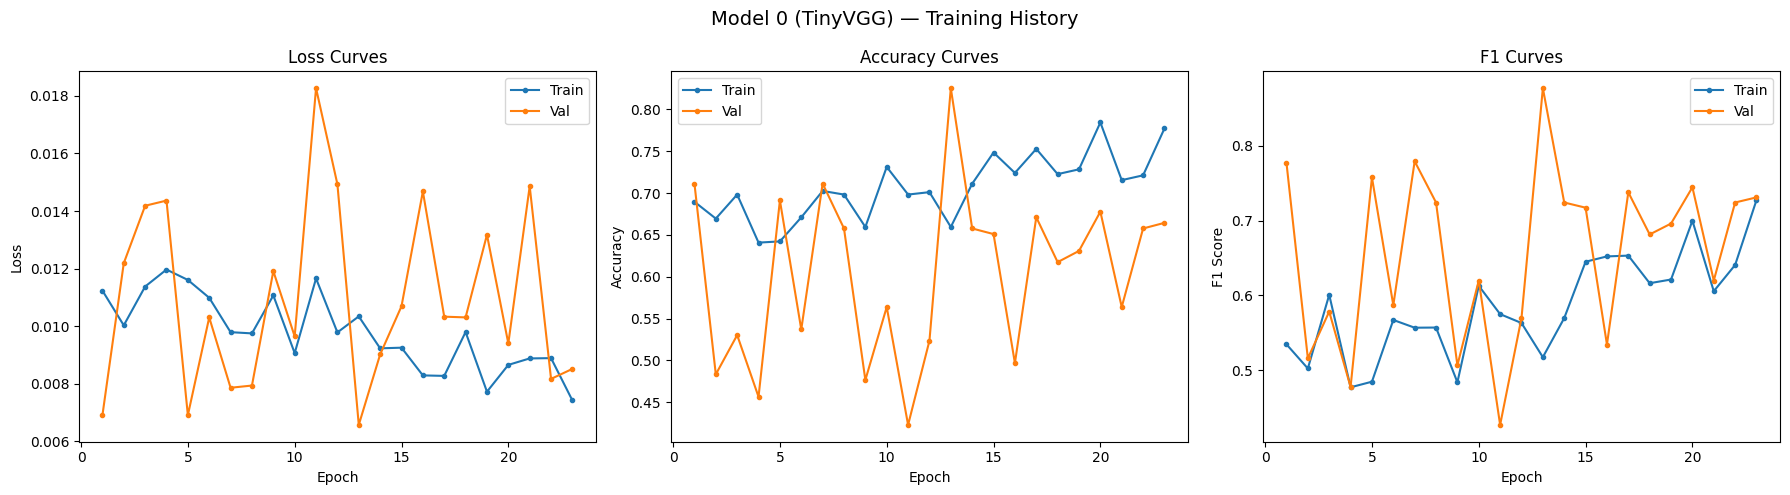

In [17]:
optimizer_0 = torch.optim.AdamW(model_0.parameters(), lr=1e-3, weight_decay=0.01)

history_0 = train_model(
    model        = model_0,
    train_loader = train_dl_0,
    val_loader   = val_dl_0,
    loss_fn      = focal_loss_fn,   # FocalLoss replaces standard_loss_fn
    optimizer    = optimizer_0,
    epochs       = 50,              # early stopping (patience=8) will cut this short
    acc_fn=acc_fn, f1_fn=f1_fn, precision_fn=precision_fn, recall_fn=recall_fn,
    device       = device,
    model_name   = "model_0_tinyvgg",
    patience     = 10
)

plot_history(history_0, "Model 0 (TinyVGG)")

### Sub-cell 8d — Test Set Evaluation

In [18]:
# model_0 already holds best-checkpoint weights (restored inside train_model)
print("--- Final Test Evaluation: Model 0 (TinyVGG) ---")
test_metrics_0 = test_step(
    model_0, test_dl_0, focal_loss_fn,
    acc_fn, f1_fn, precision_fn, recall_fn, device
)

print(f"Test Accuracy  : {test_metrics_0['accuracy']:.4f}")
print(f"Test F1 Score  : {test_metrics_0['f1']:.4f}")
print(f"Test Precision : {test_metrics_0['precision']:.4f}")
print(f"Test Recall    : {test_metrics_0['recall']:.4f}")

--- Final Test Evaluation: Model 0 (TinyVGG) ---
Test Accuracy  : 0.8200
Test F1 Score  : 0.8571
Test Precision : 0.9878
Test Recall    : 0.7570


### Sub-cell 8e — Confusion Matrix

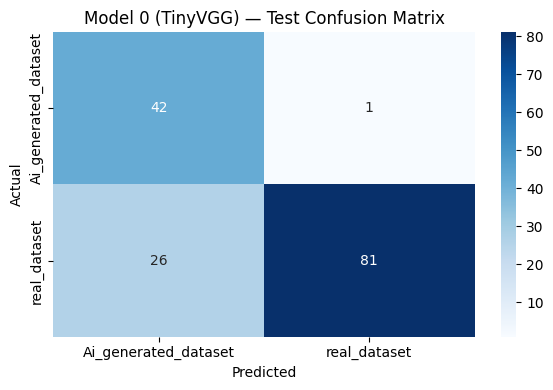

In [19]:
plot_confusion_matrix(
    model_0, test_dl_0, class_names, device,
    title="Model 0 (TinyVGG) — Test Confusion Matrix"
)

## Section 10 — LIME Interpretability

**What this does:**
Uses Local Interpretable Model-Agnostic Explanations (LIME) to highlight superpixel regions that drove the model's prediction.

**Unchanged from v1** — only the `plot_confusion_matrix` call above moved to Section 7 as a shared utility.

**Expected Output:** LIME superpixel boundary overlay for a single test image.

Generating LIME explanation for Class: real_dataset ...


100%|██████████| 1000/1000 [00:09<00:00, 108.52it/s]


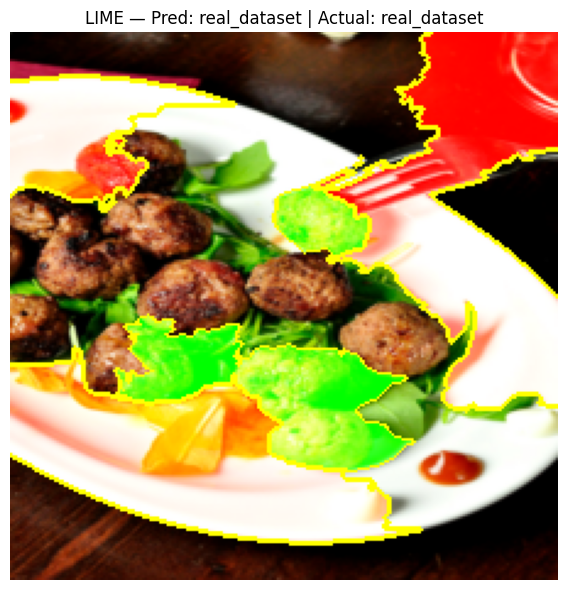

In [20]:
import lime
from lime import lime_image
from skimage.segmentation import mark_boundaries

explainer_lime = lime_image.LimeImageExplainer()

def predict_fn_lime(images):
    model_0.eval()
    _device = next(model_0.parameters()).device
    batch = torch.tensor(images, dtype=torch.float32).permute(0, 3, 1, 2)
    normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    batch = torch.stack([normalize(img) for img in batch]).to(_device)
    with torch.inference_mode():
        logits = model_0(batch)
        probs  = F.softmax(logits, dim=1)
    return probs.cpu().numpy()

model_0.eval()
sample_img_tensor, sample_label = next(iter(test_dl_0))
sample_img_tensor = sample_img_tensor[0]
sample_label      = sample_label[0].item()

inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std =[1/0.229,       1/0.224,       1/0.225]
)
img_for_lime = inv_normalize(sample_img_tensor).permute(1, 2, 0).cpu().numpy()
img_for_lime = np.clip(img_for_lime, 0, 1)

print(f"Generating LIME explanation for Class: {class_names[sample_label]} ...")
explanation = explainer_lime.explain_instance(
    img_for_lime, predict_fn_lime,
    top_labels=2, hide_color=0, num_samples=1000
)

temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0], positive_only=False, num_features=10, hide_rest=False
)
plt.figure(figsize=(6, 6))
plt.imshow(mark_boundaries(temp, mask))
plt.title(f"LIME — Pred: {class_names[explanation.top_labels[0]]} | Actual: {class_names[sample_label]}")
plt.axis('off')
plt.tight_layout()
plt.show()

## Section 11 — SHAP Interpretability

**What this does:**
Uses `shap.GradientExplainer` to produce pixel-level attribution maps showing which regions pushed the prediction toward each class.

**Unchanged from v1** — the 5D array handling fix is preserved as-is.

**Expected Output:** SHAP attribution overlay for two test images.

Generating SHAP explanations ...


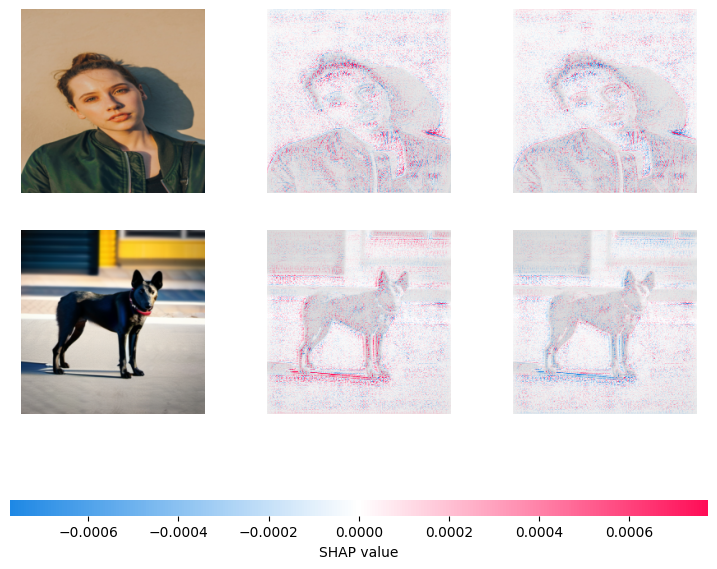

In [21]:
import shap

batch_shap        = next(iter(test_dl_0))
images_s, labels_s = batch_shap
images_s          = images_s.to(device)

print("Generating SHAP explanations ...")
background   = images_s[:24]
test_images  = images_s[22:24]

explainer_shap = shap.GradientExplainer(model_0, background)
shap_values    = explainer_shap.shap_values(test_images)

# ── Handle both list and 5-D array outputs from GradientExplainer ──
shap_numpy = []
if isinstance(shap_values, list):
    shap_numpy = [np.transpose(s, (0, 2, 3, 1)) for s in shap_values]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 5:
    for i in range(shap_values.shape[-1]):
        s_class_i = shap_values[..., i]
        shap_numpy.append(np.transpose(s_class_i, (0, 2, 3, 1)))
else:
    shap_numpy = np.transpose(shap_values, (0, 2, 3, 1))

test_numpy = np.transpose(test_images.cpu().numpy(), (0, 2, 3, 1))
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
test_numpy = np.clip(std * test_numpy + mean, 0, 1)

shap.image_plot(shap_numpy, test_numpy)